In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)

In [ ]:
sms=pd.read_csv('/content/sms_spam.csv',encoding='Latin')

In [ ]:
sms.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
sms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
sms.dtypes

,0
v1,object
v2,object
Unnamed: 2,object
Unnamed: 3,object
Unnamed: 4,object


In [ ]:
sms.shape

(5572, 5)

In [ ]:
sms.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
sms.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [ ]:
sms.columns.tolist()

['Label', 'Message']

In [ ]:
sms = pd.read_csv('/content/sms_spam.csv', encoding='Latin')
sms = sms[['v1','v2']].copy()
sms.columns = ['Label','Message']

In [ ]:
sms.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
sms['Label'].value_counts()

,count
Label,
ham,4825
spam,747


In [ ]:
sms['Label'].value_counts(normalize=True)*100

,proportion
Label,
ham,86.593683
spam,13.406317


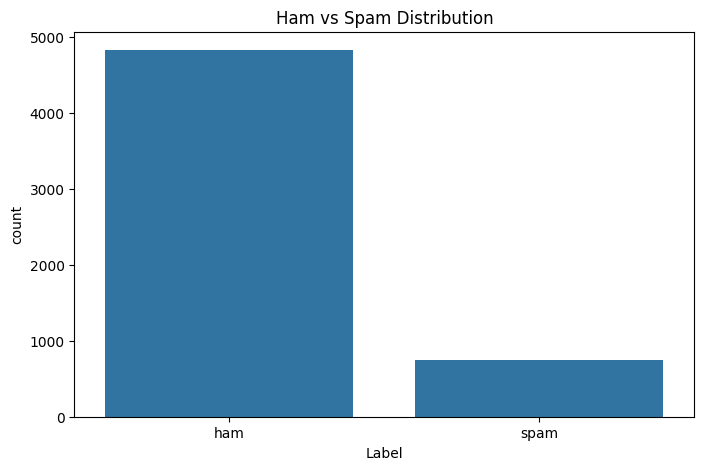

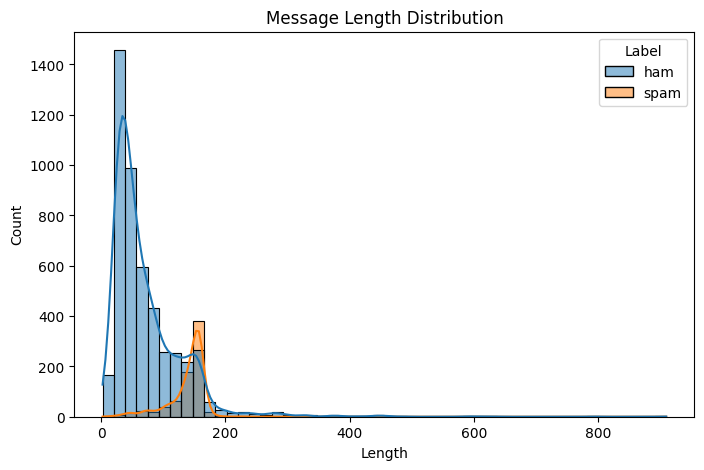

Average length of Ham messages : 71.02
Average length of Spam messages: 138.87


In [ ]:
#data visulation
plt.figure(figsize=(8,5))
sns.countplot(x='Label',data = sms  )
plt.title('Ham vs Spam Distribution')
plt.show()

#Message length analysis
sms['Length']= sms['Message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(x='Length',data=sms,hue='Label',bins=50,kde=True)
plt.title('Message Length Distribution')
plt.show()

print("Average length of Ham messages :", round(sms[sms['Label']=='ham']['Length'].mean(), 2))
print("Average length of Spam messages:", round(sms[sms['Label']=='spam']['Length'].mean(), 2))


In [ ]:
sms['Label_num']=sms['Label'].map({'ham':0,'spam':1})
print(sms[['Label', 'Label_num']].head(10))

  Label  Label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0
5  spam          1
6   ham          0
7   ham          0
8  spam          1
9  spam          1


In [ ]:
x= sms['Message']
y= sms['Label']

print('Total Messages :',len(x))

Total Messages : 5572


In [ ]:
x_train , x_test , y_train , y_test = train_test_split(
    x,y, test_size=0.2 , random_state=42 , stratify=y
)
print('Training Sample', len(x_train))
print('Testing Sample', len(x_test))

Training Sample 4457
Testing Sample 1115


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
x_train_cv = vectorizer.fit_transform(x_train)
x_test_cv = vectorizer.transform(x_test)


print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Training features shape:", x_train_cv.shape)
print("Testing features shape :", x_test_cv.shape)

Vocabulary size: 7440
Training features shape: (4457, 7440)
Testing features shape : (1115, 7440)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(x_train_cv, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [ ]:
y_pred = model.predict(x_test_cv)

print("First 10 Actual labels   :", y_test.values[:10])
print("First 10 Predicted labels:", y_pred[:10])

First 10 Actual labels   : ['ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']
First 10 Predicted labels: ['ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


Accuracy: 98.39%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix:
[[960   6]
 [ 12 137]]


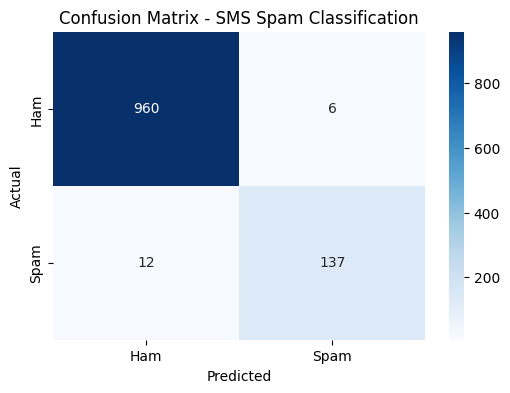

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title("Confusion Matrix - SMS Spam Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
sample_message = ["Congratulations! You have won a free lottery of $10000. Call now!",
    "Hi, are we still meeting for lunch today?",
    "URGENT! Your account has been suspended. Click here to verify.",
    "Don't forget to bring the documents tomorrow.",
    "Free entry in 2 a weekly competition to win FA Cup final tickets."]

sample_vec= vectorizer.transform(sample_message)
predictions = model.predict(sample_vec)
probability = model.predict_proba(sample_vec)


print("Predictions on new messages:\n")
for msg, pred, prob in zip(sample_message, predictions, probability):
    label = "SPAM" if pred == 'spam' else "HAM" # Corrected condition
    print(f"Message: {msg[:60]}...")
    print(f"Prediction: {label} (Spam probability: {prob[1]*100:.2f}%)\n")

Predictions on new messages:

Message: Congratulations! You have won a free lottery of $10000. Call...
Prediction: SPAM (Spam probability: 99.11%)

Message: Hi, are we still meeting for lunch today?...
Prediction: HAM (Spam probability: 0.00%)

Message: URGENT! Your account has been suspended. Click here to verif...
Prediction: SPAM (Spam probability: 99.43%)

Message: Don't forget to bring the documents tomorrow....
Prediction: HAM (Spam probability: 0.02%)

Message: Free entry in 2 a weekly competition to win FA Cup final tic...
Prediction: SPAM (Spam probability: 100.00%)

